In [1]:
# notebook to analyse results in src/results
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial import distance as dist

import torch.nn.functional as F

# super-resolution

In [ ]:
classification = ''#'classification_'
models_results = pd.read_csv(f'../results/yelp2019/super_resolution_GNN_{classification}results.csv', index_col=0)


results_df = pd.DataFrame(models_results)

rounding = 1

metric = 'r2'
# considere model_embeddigns only from the following
model_embeddings = ['NoPreTrain', 'Emb', 'RGNN', 'Feat-RGNN', 'Feat\\&PC-RGNN', 'LightGCN',
                    'Feat-LightGCN', 'Feat\\&PC-LightGCN']

if metric != 'r2':
    results_df.loc[:, f'test_{metric}'] *= 100
    results_df.loc[:, f'train_to_test_{metric}'] *= 100

results_df['baseline_diff'] = results_df[f'test_{metric}'] - results_df[f'train_to_test_{metric}']

results_df_filtered = results_df[results_df['model_embeddings'].isin(model_embeddings)]
# group by macroentity,urban_area, target variable and model embedding, then compute mean and std of metrics
results_summary = results_df_filtered.groupby(['macroentity', 'urban_area', 'target_variable', 'model_embeddings']).agg({f'test_{metric}': ['mean', 'std'],
                                                                                                                   f'train_to_test_{metric}': ['mean', 'std'],
                                                                                                                   'baseline_diff': ['mean', 'std']}).reset_index()

# divide std by sqrt of number of samples to get standard error
results_summary[(f'test_{metric}', 'std')] = results_summary[(f'test_{metric}', 'std')] / np.sqrt(results_df_filtered.groupby(['macroentity', 'urban_area', 'target_variable', 'model_embeddings']).size().values)
results_summary[(f'train_to_test_{metric}', 'std')] = results_summary[(f'train_to_test_{metric}', 'std')] / np.sqrt(results_df_filtered.groupby(['macroentity', 'urban_area', 'target_variable', 'model_embeddings']).size().values)
results_summary[('baseline_diff', 'std')] = results_summary[('baseline_diff', 'std')] / np.sqrt(results_df_filtered.groupby(['macroentity', 'urban_area', 'target_variable', 'model_embeddings']).size().values)
# create a new column 'baseline_diff_string' to store the rounded baseline diff as string with
# round baseline diff to 1 decimal and add + sign if positive
results_summary[('baseline_diff', 'string')] = results_summary[('baseline_diff', 'mean')].round(rounding).apply(lambda x: f'+{x}' if x > 0 else f'{x}')
# aggregate results as a summary column with 'test_metric mean ± std (baseline diff)' as entries
results_summary['summary'] = results_summary[(f'test_{metric}', 'mean')].round(rounding).astype(str) + '±' + results_summary[(f'test_{metric}', 'std')].round(rounding).astype(str) + ' ('+ results_summary[('baseline_diff', 'string')] + ')'

# --- new: add one row per (macroentity, target_variable, model_embeddings) where urban_area is "Average"
# and 'summary' is the average baseline_diff across urban_areas (formatted like the baseline_diff string)
avg_baseline = results_summary.groupby(['macroentity', 'target_variable', 'model_embeddings'])[[('baseline_diff', 'mean'),]].mean().reset_index()
avg_baseline['urban_area'] = 'Average'
avg_baseline[('baseline_diff', 'string')] = avg_baseline[('baseline_diff', 'mean')].round(rounding).apply(lambda x: f'+{x}' if x > 0 else f'{x}')
# set the summary to be the average baseline diff string (user requested summary to be the average baseline diff)
avg_baseline['summary'] = avg_baseline[('baseline_diff', 'string')]

# ensure avg_baseline has same columns as results_summary (fill missing with NaN)
for col in results_summary.columns:
    if col not in avg_baseline.columns:
        avg_baseline[col] = np.nan

# reorder columns to match and append
avg_baseline = avg_baseline[results_summary.columns]
results_summary = pd.concat([results_summary, avg_baseline], ignore_index=True, sort=False)



# order urban areas as Philadelphia, Tampa, Indianapolis, St. Louis, Nashville
urban_area_order = ['Philadelphia', 'Tampa', 'Indianapolis', 'St. Louis', 'Nashville', 'Average']
results_summary['urban_area'] = pd.Categorical(results_summary['urban_area'], categories=urban_area_order, ordered=True)
# order model embeddings as in model_embeddings list
results_summary['model_embeddings'] = pd.Categorical(results_summary['model_embeddings'], categories=model_embeddings, ordered=True)
# sort results_summary by macroentity, target variable, model embeddings and urban area
results_summary = results_summary.sort_values(by=['macroentity', 'target_variable', 'model_embeddings', 'urban_area'])
results_summary = results_summary.loc[results_summary.macroentity == 'zip']
results_summary = results_summary.loc[results_summary.model_embeddings.isin(['NoPreTrain', 'Emb', 'LightGCN', 'Feat-LightGCN', 'Feat\\&PC-LightGCN'])]

# pivot table to have urban_area values as columns
results_pivot = results_summary.pivot_table(index=['macroentity', 'target_variable', 'model_embeddings'], columns='urban_area', values='summary', aggfunc='first').reset_index()


# save results_pivot to tex file, formatted as a latex table
#results_pivot.to_latex('../results/yelp2019/super_resolution_GNN_classification_results_summary.tex', index=False, escape=False)
results_pivot

/tmp/ipykernel_219466/61714796.py:65: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  results_pivot = results_summary.pivot_table(index=['macroentity', 'target_variable', 'model_embeddings'], columns='urban_area', values='summary', aggfunc='first').reset_index()
/tmp/ipykernel_219466/61714796.py:65: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  results_pivot = results_summary.pivot_table(index=['macroentity', 'target_variable', 'model_embeddings'], columns='urban_area', values='summary', aggfunc='first').reset_index()


macroentity    target_variable   model_embeddings  \
urban_area                                                     
0                  zip         Median Age         NoPreTrain   
1                  zip         Median Age                Emb   
2                  zip         Median Age           LightGCN   
3                  zip         Median Age      Feat-LightGCN   
4                  zip         Median Age  Feat\&PC-LightGCN   
5                  zip  Median Home Value         NoPreTrain   
6                  zip  Median Home Value                Emb   
7                  zip  Median Home Value           LightGCN   
8                  zip  Median Home Value      Feat-LightGCN   
9                  zip  Median Home Value  Feat\&PC-LightGCN   
10                 zip      Median Income         NoPreTrain   
11                 zip      Median Income                Emb   
12                 zip      Median Income           LightGCN   
13                 zip      Median Income      Feat-LightGCN   
14                 zip      Median Income  Feat\&PC-LightGCN   

                                                                       \
urban_area        Philadelphia               Tampa       Indianapolis   
0            -86.4±4.4 (-99.6)  -75.5±3.5 (-114.8)  -19.9±2.6 (-23.4)   
1            -12.9±1.1 (-26.1)    -7.8±1.5 (-47.2)  -19.8±2.1 (-23.3)   
2             -2.8±0.6 (-16.0)    10.3±1.6 (-29.1)  -20.4±1.1 (-23.9)   
3              0.6±0.4 (-12.6)     4.4±1.3 (-34.9)  -21.6±1.1 (-25.1)   
4               9.3±0.2 (-3.9)     32.8±0.3 (-6.6)    -4.2±0.2 (-7.7)   
5           -63.6±7.7 (-122.2)   -29.8±3.0 (-72.3)   13.4±1.5 (-27.5)   
6              1.0±2.1 (-57.6)    16.4±0.8 (-26.2)   23.2±0.6 (-17.7)   
7             39.1±0.7 (-19.5)    30.4±0.5 (-12.2)  -14.2±4.4 (-55.1)   
8             34.8±1.3 (-23.8)    25.9±0.6 (-16.7)   15.2±1.1 (-25.7)   
9             47.1±0.3 (-11.5)     34.7±0.3 (-7.8)    37.3±0.3 (-3.6)   
10           -52.4±4.1 (-98.6)   -21.0±2.4 (-54.0)   11.3±2.3 (-31.0)   
11             9.8±1.5 (-36.4)    12.7±1.0 (-20.3)   13.4±0.9 (-29.0)   
12            29.7±0.8 (-16.6)    21.0±0.3 (-12.1)   -3.0±4.7 (-45.3)   
13            28.6±0.7 (-17.6)    22.2±0.2 (-10.9)    6.6±2.1 (-35.7)   
14             41.5±0.2 (-4.8)     23.7±0.2 (-9.3)    34.7±0.4 (-7.7)   

                                                           
urban_area          St. Louis           Nashville Average  
0            10.6±1.3 (-13.4)    -1.1±1.2 (-10.8)   -52.4  
1             8.4±0.4 (-15.7)   -10.6±0.7 (-20.2)   -26.5  
2             14.4±0.5 (-9.7)     -0.1±0.4 (-9.8)   -17.7  
3             14.2±0.6 (-9.9)    -3.2±1.2 (-12.8)   -19.0  
4             20.7±0.2 (-3.4)      7.5±0.2 (-2.1)    -4.7  
5           -10.3±4.7 (-63.8)   -31.1±2.2 (-13.7)   -59.9  
6           -18.3±2.3 (-71.8)   -42.4±1.2 (-25.0)   -39.7  
7            23.2±1.2 (-30.3)  -105.1±4.1 (-87.8)   -41.0  
8            11.7±1.5 (-41.8)   -94.6±3.5 (-77.2)   -37.0  
9             43.9±0.3 (-9.6)    -17.3±0.7 (+0.1)    -6.5  
10           12.4±1.7 (-20.6)    -8.4±2.4 (-25.6)   -46.0  
11           18.0±1.0 (-14.9)   -40.7±1.2 (-57.9)   -31.7  
12            8.0±1.5 (-25.0)   -14.0±2.2 (-31.1)   -26.0  
13           15.2±0.8 (-17.7)   -33.2±1.5 (-50.3)   -26.5  
14            31.4±0.2 (-1.6)     18.7±0.6 (+1.6)    -4.4

In [13]:
import seaborn as sns
import matplotlib as mpl

cmaps = {}

# create a colormap for each macroentity, target_variable and urban_area
cmaps_name = 'Greens'

norm = plt.Normalize(-10, 0, clip=True)


for ua in results_summary['urban_area'].unique():
    curr_values = []
    for me in results_summary['macroentity'].unique():
        for tv in results_summary['target_variable'].unique():
            cmap = sns.color_palette(cmaps_name, as_cmap=True)
            values = results_summary[(results_summary['macroentity'] == me) & 
                                     (results_summary['target_variable'] == tv) & 
                                     (results_summary['urban_area'] == ua)]['baseline_diff']['mean'].values
            curr_values.extend(cmap(norm(values)))
    cmaps[ua] = curr_values



import matplotlib as mpl

def relative_luminance(rgba) -> float:
            """
            Calculate relative luminance of a color.

            The calculation adheres to the W3C standards
            (https://www.w3.org/WAI/GL/wiki/Relative_luminance)

            Parameters
            ----------
            color : rgb or rgba tuple

            Returns
            -------
            float
                The relative luminance as a value from 0 to 1
            """
            r, g, b = (
                x / 12.92 if x <= 0.04045 else ((x + 0.055) / 1.055) ** 2.4
                for x in rgba[:3]
            )
            return 0.2126 * r + 0.7152 * g + 0.0722 * b


def custom_background(s):
    text_color_threshold = 0.38
    ua = s.name[1]

    curr_cmap = cmaps[ua]
    text_darks = ['dark' if relative_luminance(curr_cmap[i]) < text_color_threshold else 'light' for i in range(len(s))]
    text_colors = ["#f1f1f1" if x == 'dark' else "#000000" for x in text_darks]

    return ['cellcolor:[HTML]{{{}}}; color:[HTML]{{{}}}'.format(mpl.colors.rgb2hex(curr_cmap[i])[1:], text_colors[i][1:]) for i in range(len(s))]

# apply to results_pivot
results_pivot_styled = results_pivot.style.apply(custom_background, axis=0, subset=results_pivot.columns[3:])

results_pivot_styled.to_latex('../results/yelp2019/super_resolution_GNN_classification_results_summary_colored.tex')

In [14]:
def custom_background(s):
    text_color_threshold = 0.38
    ua = s.name[1]

    curr_cmap = cmaps[ua]
    text_darks = ['dark' if relative_luminance(curr_cmap[i]) < text_color_threshold else 'light' for i in range(len(s))]
    text_colors = ["#f1f1f1" if x == 'dark' else "#000000" for x in text_darks]

    return ['background-color:{}; color:{}'.format(mpl.colors.rgb2hex(curr_cmap[i]), text_colors[i]) for i in range(len(s))]

# apply to results_pivot
results_pivot_styled = results_pivot.style.apply(custom_background, axis=0, subset=results_pivot.columns[3:])
results_pivot_styled

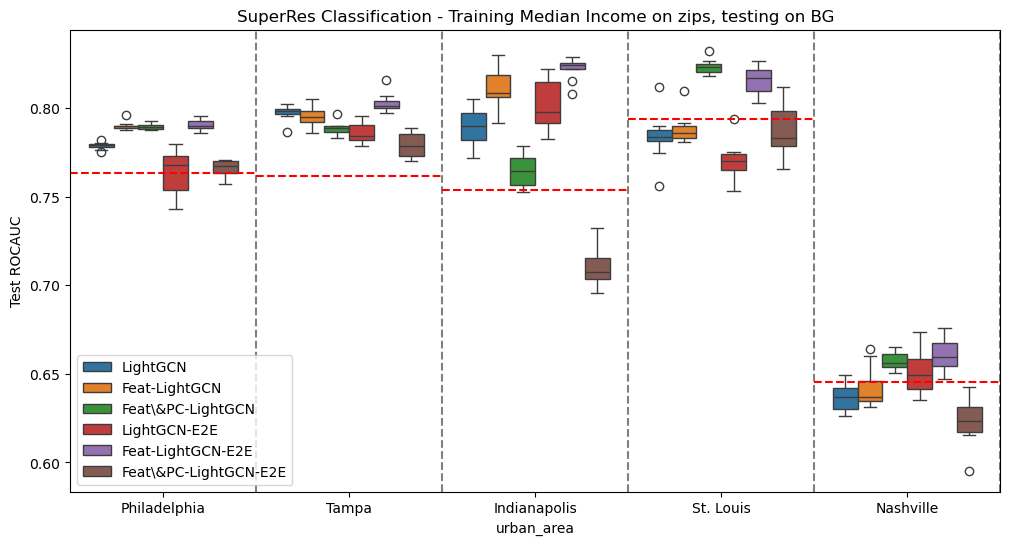

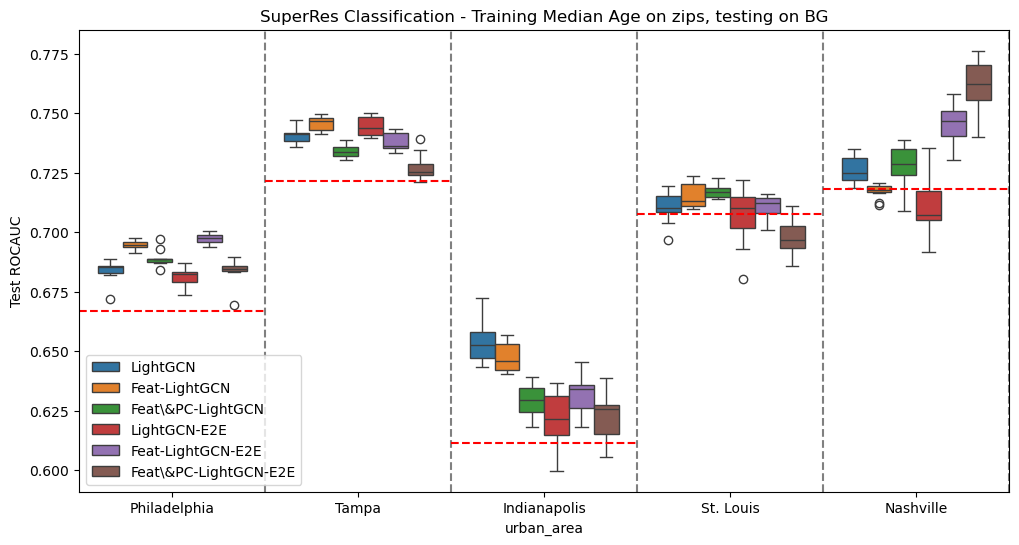

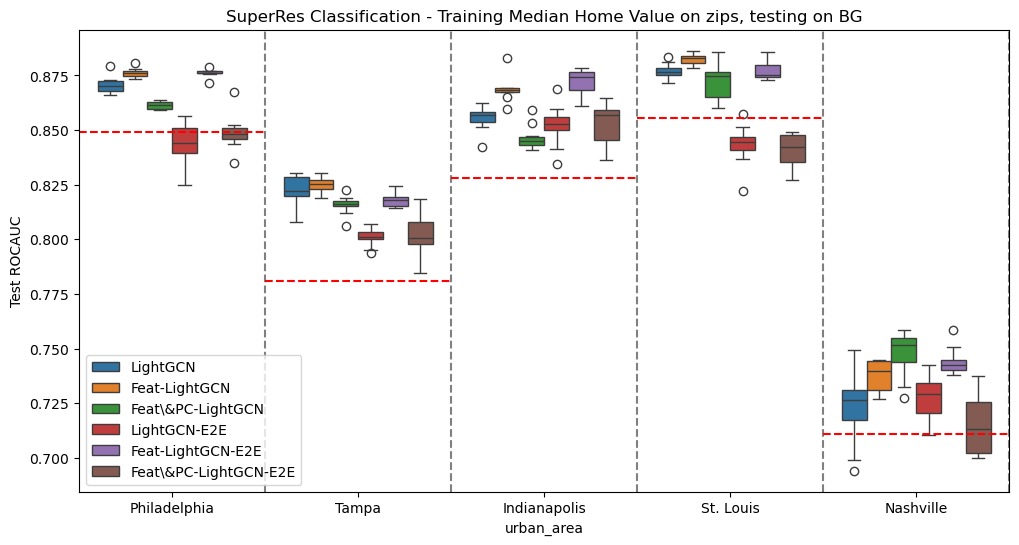

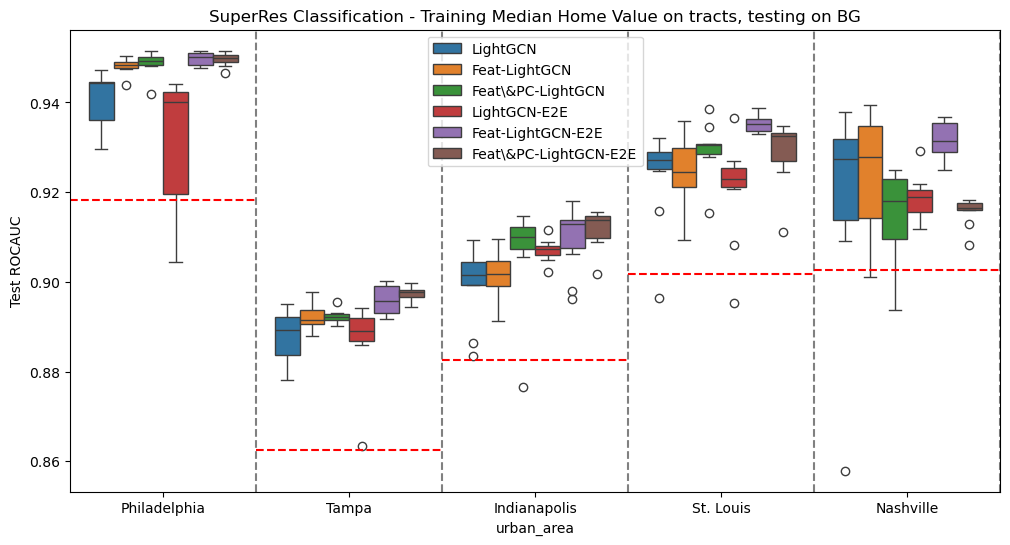

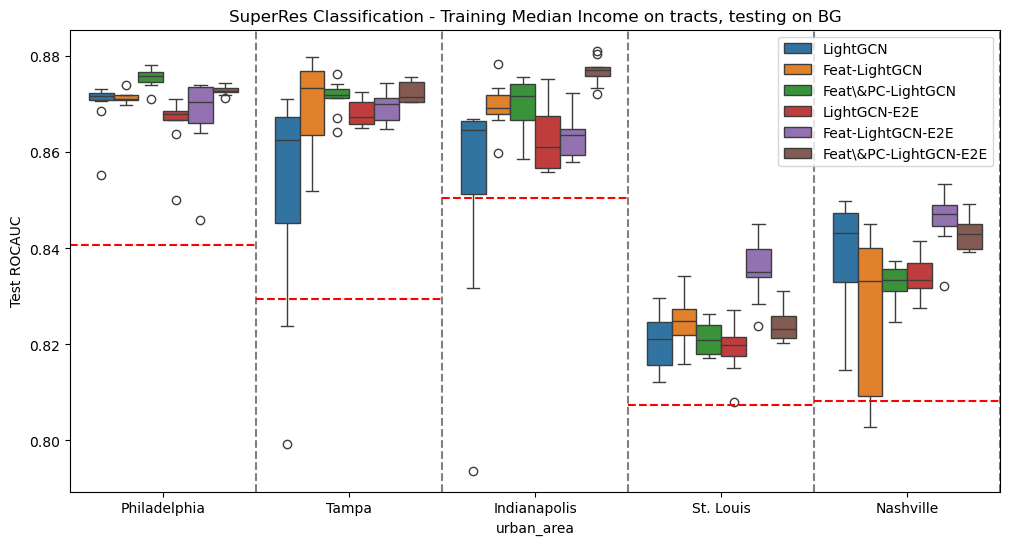

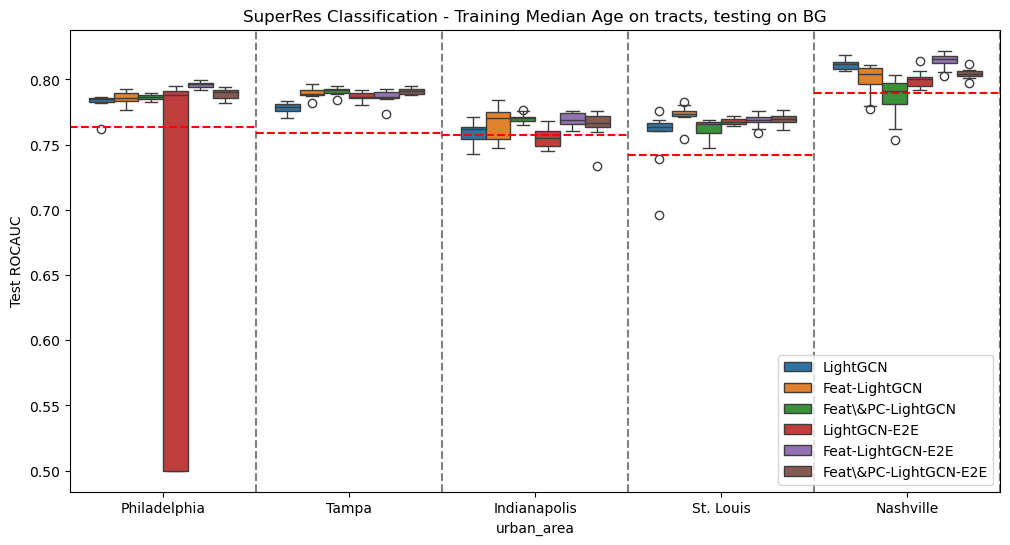

In [2]:
models_results = pd.read_csv('../results/yelp2019/super_resolution_GNN_classification_results.csv', index_col=0)
model_e2e_results = pd.read_csv('../results/yelp2019/super_resolution_E2E_classification_results.csv', index_col=0)
results_df = pd.DataFrame(models_results)
e2e_results_df = pd.DataFrame(model_e2e_results)
e2e_results_df['model_embeddings'] = e2e_results_df['model_embeddings'] + '-E2E'
results_df = pd.concat([results_df, e2e_results_df], ignore_index=True)


model_embeddings = [ 'LightGCN',#'Random', 'Emb', 'RGNN', 'Feat-RGNN', 'Feat\\&PC-RGNN', 
                    'Feat-LightGCN', 'Feat\\&PC-LightGCN']
model_embeddings += [me + '-E2E' for me in model_embeddings if me in ['LightGCN','Feat-LightGCN','Feat\\&PC-LightGCN']]
results_df = results_df.loc[results_df['model_embeddings'].isin(model_embeddings)]
# order the results by model embeddings
results_df['model_embeddings'] = pd.Categorical(results_df['model_embeddings'], categories=model_embeddings, ordered=True)
results_df = results_df.sort_values('model_embeddings')

variables = ['Median Age', 'Median Income', 'Median Home Value',]
results_df = results_df.loc[results_df['target_variable'].isin(variables)]

# sort by urban_area in order Philadelphia Tampa Indianapolis St. Louis Nashville
urban_area_order = ['Philadelphia', 'Tampa', 'Indianapolis', 'St. Louis', 'Nashville']
results_df['urban_area'] = pd.Categorical(results_df['urban_area'], categories=urban_area_order, ordered=True)
results_df = results_df.sort_values('urban_area')

for macroentity in results_df['macroentity'].unique():
    curr_agg_results = results_df[results_df['macroentity'] == macroentity]
    # plot test_MAE by model type and urban_area for each target_variable
    for target in curr_agg_results['target_variable'].unique():

        curr_data = curr_agg_results[curr_agg_results['target_variable'] == target]
        fig, ax = plt.subplots(1, 1, figsize=(12, 6))
        sns.boxplot(data=curr_data, x='urban_area', y='test_ROCAUC', hue='model_embeddings',  ax=ax)

        for k in range(5):
            urban_area = urban_area_order[k]
            urban_area_data = curr_agg_results[(curr_agg_results['target_variable'] == target) & (curr_agg_results['urban_area'] == urban_area)]
            train_to_test_rocauc = urban_area_data['train_to_test_ROCAUC'].values[0]
            ax.axvline(x=k+0.5, color='grey', linestyle='--')
            ax.hlines(y=train_to_test_rocauc, xmin=k-0.5, xmax=k+0.5, color='red', linestyle='--')
        ax.set_title(f'SuperRes Classification - Training {target} on {macroentity}s, testing on BG')
        ax.set_ylabel('Test ROCAUC')
        ax.legend()
        ax.set_xlim(-0.5, 4.5)
        #plt.ylim(0.5, 1)
        plt.show()
        # save figure
        fig.savefig(f'../results/figures/superres_classification_{target}_{macroentity}_test_ROCAUC.pdf')

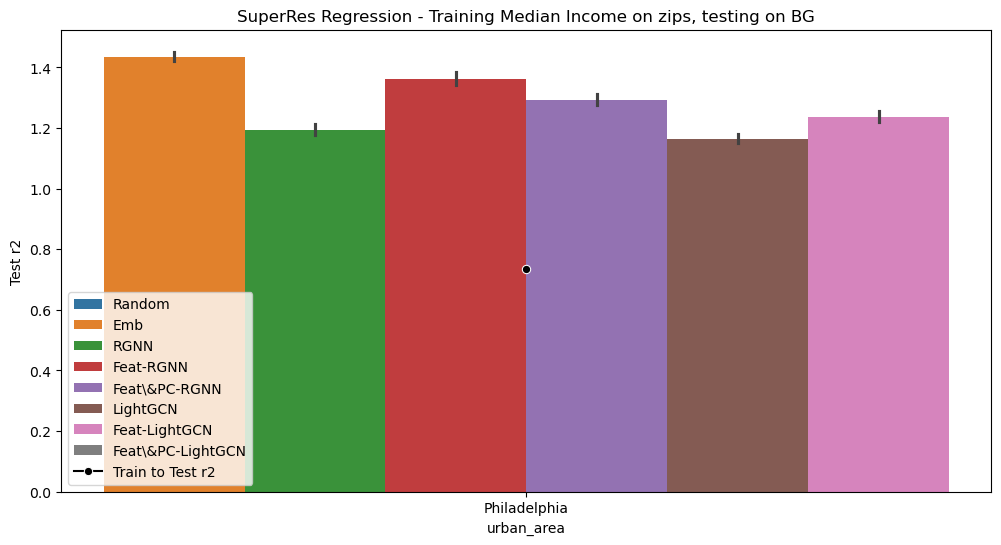

In [3]:
models_results = pd.read_csv('../results/yelp2019/super_resolution_GNN_results.csv', index_col=0)

results_df = pd.DataFrame(models_results)

model_embeddings = ['Random', 'Emb', 'RGNN', 'Feat-RGNN', 'Feat\\&PC-RGNN', 'LightGCN',
                    'Feat-LightGCN', 'Feat\\&PC-LightGCN']
results_df = results_df.loc[results_df['model_embeddings'].isin(model_embeddings)]
# order the results by model embeddings
results_df['model_embeddings'] = pd.Categorical(results_df['model_embeddings'], categories=model_embeddings, ordered=True)
results_df = results_df.sort_values('model_embeddings') 
variables = ['Median Age', 'Median Income', 'Median Home Value',]
results_df = results_df.loc[results_df['target_variable'].isin(variables)]


for macroentity in results_df['macroentity'].unique():
    curr_agg_results = results_df[results_df['macroentity'] == macroentity]
    # plot test_MAE by model type and urban_area for each target_variable
    for target in curr_agg_results['target_variable'].unique():
        fig, ax = plt.subplots(1, 1, figsize=(12, 6))
        sns.barplot(data=curr_agg_results[curr_agg_results['target_variable'] == target], x='urban_area', y=f'test_mae', hue='model_embeddings', errorbar='se', ax=ax)
        # use train_to_test_MAE as lines
        sns.lineplot(data=curr_agg_results[curr_agg_results['target_variable'] == target], x='urban_area', y=f'train_to_test_mae', marker='o', color='black', label='Train to Test r2', ax=ax)
        ax.set_title(f'SuperRes Regression - Training {target} on {macroentity}s, testing on BG')
        ax.set_ylabel('Test r2')
        ax.legend()
        #plt.ylim(0.5, 1)
        plt.show()
        fig.savefig(f'../results/figures/superres_regression_{target}_{macroentity}_test_r2.pdf')

# Interpolation

In [ ]:
models_results = pd.read_csv('../results/yelp2019/interpolation_GNN_results.csv', index_col=0)

results_df = pd.DataFrame(models_results)

model_embeddings = ['Random', 'Emb', 'RGNN', 'Feat-RGNN', 'Feat\\&PC-RGNN', 'LightGCN',
                    'Feat-LightGCN', 'Feat\\&PC-LightGCN']

results_df = results_df.loc[results_df['model_embeddings'].isin(model_embeddings)]
# order the results by model embeddings
results_df['model_embeddings'] = pd.Categorical(results_df['model_embeddings'], categories=model_embeddings, ordered=True)
results_df = results_df.sort_values('model_embeddings')
# order urban_area in order Philadelphia Tampa Indianapolis St. Louis Nashville
urban_area_order = ['Philadelphia', 'Tampa', 'Indianapolis', 'St. Louis', 'Nashville']
results_df['urban_area'] = pd.Categorical(results_df['urban_area'], categories=urban_area_order, ordered=True)

for macroentity in results_df['target_entity'].unique():
    curr_agg_results = results_df[results_df['target_entity'] == macroentity]
    # plot test_MAE by model type and urban_area for each target_variable
    for target in curr_agg_results['target_variable'].unique():
        fig, ax = plt.subplots(1, 1, figsize=(12, 6))
        sns.boxplot(data=curr_agg_results[curr_agg_results['target_variable'] == target], x='urban_area', y=f'test_mae', hue='model_embeddings', ax=ax)
        for k in range(5):
            ax.axvline(x=k+0.5, color='grey', linestyle='--')
        ax.set_title(f'Interpolation: Training {target} for {macroentity}s')
        ax.set_ylabel('Test MAE')
        ax.legend()
        fig.savefig(f'../results/figures/interpolation_{target}_{macroentity}_test_mae.pdf')
        #plt.ylim(0.5, 1)
        plt.show()

In [8]:
results_df['target_entity'].unique()

array(['zip', 'bg', 'tract'], dtype=object)

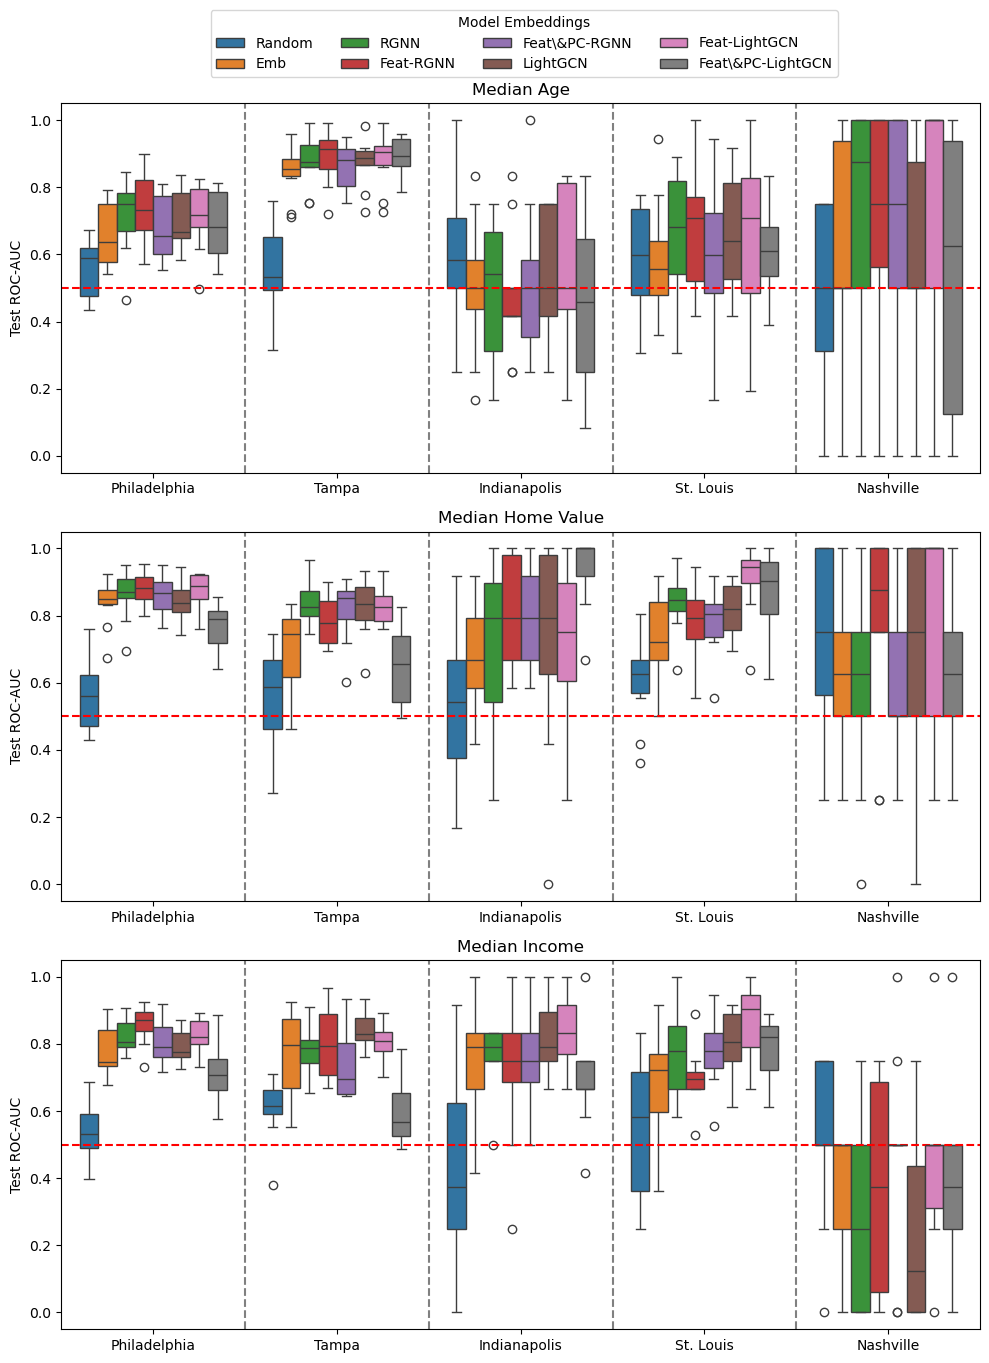

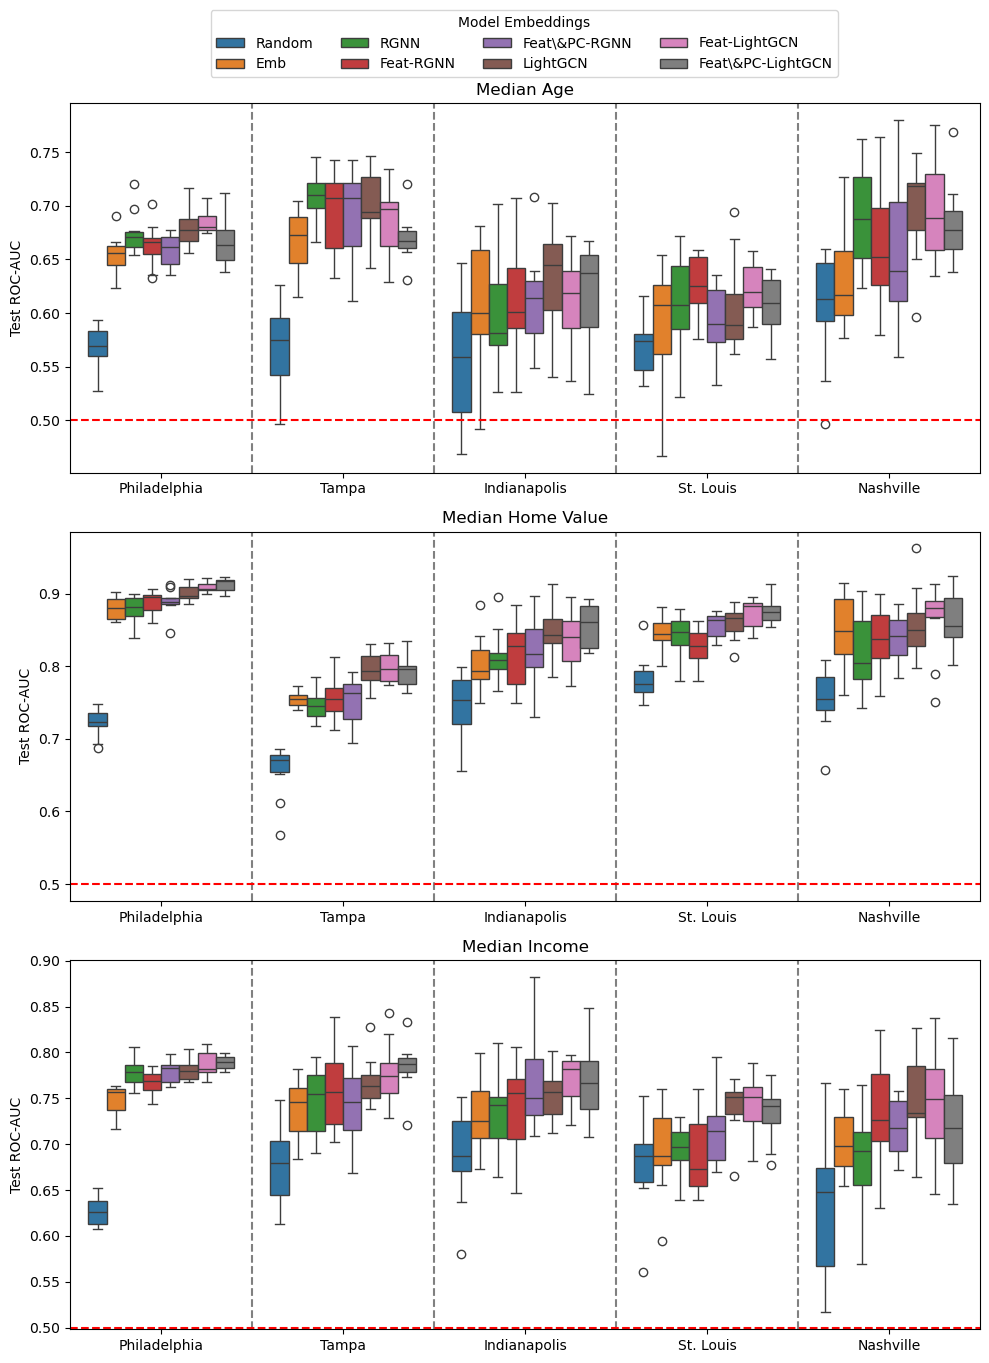

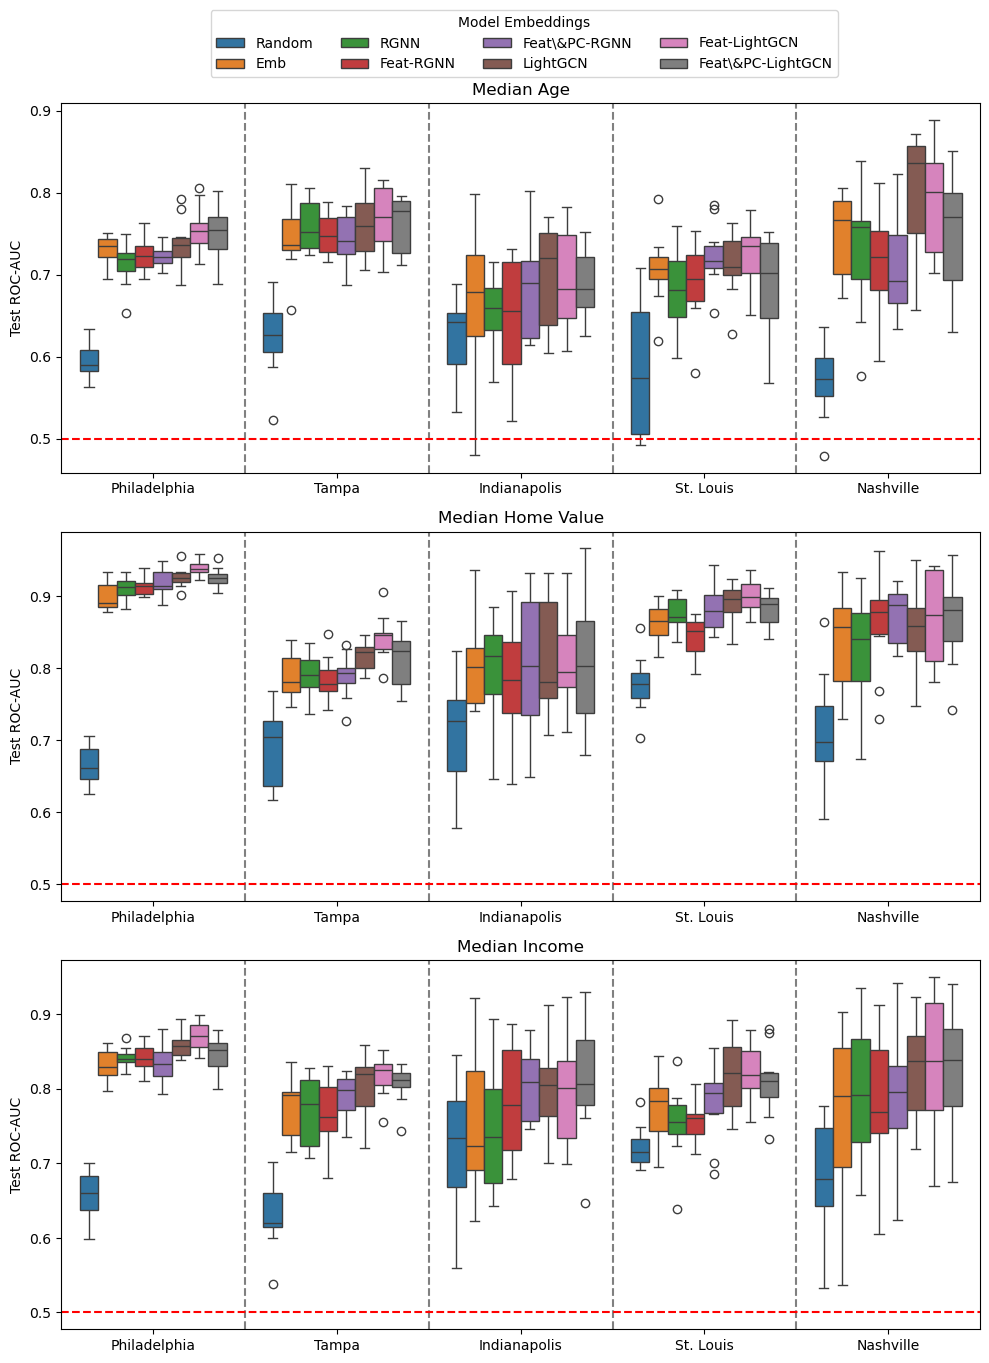

In [11]:
models_results = pd.read_csv('../results/yelp2019/interpolation_GNN_results_classification.csv', index_col=0)
#model_e2e_results = pd.read_csv('../results/yelp2019/interpolation_E2E_results_classification.csv', index_col=0)

results_df = pd.DataFrame(models_results)

model_embeddings = ['Random','Emb', 'RGNN', 'Feat-RGNN', 'Feat\\&PC-RGNN',  'LightGCN', #
                    'Feat-LightGCN', 'Feat\\&PC-LightGCN']

results_df = results_df.loc[results_df['target_variable'].isin(['Median Age', 'Median Income', 'Median Home Value'])]

results_df = results_df.loc[results_df['model_embeddings'].isin(model_embeddings)]
# order the results by model embeddings
results_df['model_embeddings'] = pd.Categorical(results_df['model_embeddings'], categories=model_embeddings, ordered=True)
results_df = results_df.sort_values('model_embeddings')
# order urban_area in order Philadelphia Tampa Indianapolis St. Louis Nashville
urban_area_order = ['Philadelphia', 'Tampa', 'Indianapolis', 'St. Louis', 'Nashville']
results_df['urban_area'] = pd.Categorical(results_df['urban_area'], categories=urban_area_order, ordered=True)
results_df = results_df.sort_values('target_variable')

for macroentity in results_df['target_entity'].unique():

        
    curr_agg_results = results_df[results_df['target_entity'] == macroentity]




    
    # plot test_MAE by model type and urban_area for each target_variable
    fig, axs = plt.subplots(3, 1, figsize=(10, 13))
    for k, target in enumerate(curr_agg_results['target_variable'].unique()):
        ax = axs[k]
        sns.boxplot(data=curr_agg_results[curr_agg_results['target_variable'] == target], x='urban_area', y=f'test_score', hue='model_embeddings',  ax=ax, legend=k==2)
        # use train_to_test_MAE as lines
        ax.set_title(f'{target}')
        ax.set_ylabel('Test ROC-AUC')
        ax.set_xlabel('')
        if k==2:
            ax.get_legend().remove()

       
        
        # plot vertical lines to separate urban_areas
        for i in range(1, 5):
            ax.axvline(x=i-0.5, color='grey', linestyle='--')


        # # if macroentity == 'bg', recover from the super_resolution results the train_to_test_ROCAUC and plot as horizontal lines
        # if macroentity == 'bg':
        #     sr_results = pd.read_csv('../results/yelp2019/super_resolution_GNN_classification_results.csv', index_col=0)
        #     sr_results_df = pd.DataFrame(sr_results)
        #     sr_results_df = sr_results_df.loc[sr_results_df['model_embeddings'].isin(model_embeddings)]
        #     sr_results_df = sr_results_df.loc[sr_results_df['target_variable'].isin(['Median Age', 'Median Income', 'Median Home Value'])]
        #     urban_area_order = ['Philadelphia', 'Tampa', 'Indianapolis', 'St. Louis', 'Nashville']
        #     for j, urban_area in enumerate(urban_area_order):
        #         urban_area_data = sr_results_df[(sr_results_df['target_variable'] == target) & (sr_results_df['urban_area'] == urban_area) & (sr_results_df['macroentity'] == 'zip')]
        #         train_to_test_rocauc = urban_area_data['train_to_test_ROCAUC'].values[0]
        #         ax.hlines(y=train_to_test_rocauc, xmin=j-0.5, xmax=j+0.5, color='black', linestyle='--')
        # else:
        # plot horizontal line at 0.5
        ax.axhline(y=0.5, color='red', linestyle='--')

    fig.legend(title='Model Embeddings', ncols=4, bbox_to_anchor=(0.85, 1.05))
    fig.tight_layout()
    fig.savefig(f'../results/figures/interpolation_{macroentity}_test_ROC-AUC.pdf', bbox_inches='tight')
    #plt.ylim(0.5, 1)
    plt.show()

# Model performances

In [ ]:
sns.set_context("paper", font_scale=1.5)

city = 'yelp2019'
df = pd.DataFrame()

model_names = [ "NoEdges", "NoFeatures",  "FeatAndEmb", "FeatAndEmbAndPostalCode", 
               "FeatAndEmbAndBG", "LightGCN", "FeatLightGCN", "FeatAndPCLightGCN", 
               "FeatAndBGLightGCN", "NoEdges", ] #  'LightGCN_with_sentiment_scores', 'FeatLightGCN_with_sentiment_scores', 'FeatAndPCLightGCN_with_sentiment_scores'

model_better_names = {"NoEdges": "Emb", "NoFeatures": "RGCN", "FeatAndEmb": "Feat-RGCN", "FeatAndEmbAndPostalCode": "Feat&PC-RGCN",
                       "LightGCN": "LightGCN", "FeatLightGCN": "Feat-LightGCN", "FeatAndPCLightGCN": "Feat&PC-LightGCN", 
                       "LightGCN_with_sentiment_scores": "LightGCN+Sentiment", "FeatLightGCN_with_sentiment_scores": "Feat-LightGCN+Sentiment",
                       "FeatAndPCLightGCN_with_sentiment_scores": "Feat&PC-LightGCN+Sentiment", "FeatAndEmbAndBG": "Feat&BG-RGCN",
                       "FeatAndBGLightGCN": "Feat&BG-LightGCN"}

model_info = {"NoEdges": "Graph", "NoFeatures": "Graph",  "FeatAndEmb": "Graph with Feat.", "FeatAndEmbAndPostalCode": "Graph with Feat. and PCs",
              "LightGCN": "Graph", "FeatLightGCN": "Graph with Feat.", "FeatAndPCLightGCN": "Graph with Feat. and PCs", 
              "LightGCN_with_sentiment_scores": "Graph and sentiments", "FeatLightGCN_with_sentiment_scores": "Graph with Feat. and sentiments", 
              "FeatAndPCLightGCN_with_sentiment_scores": "Graph with Feat., PCs and sentiments", "FeatAndEmbAndBG": "Graph with Feat. and BG",
              "FeatAndBGLightGCN": "Graph with Feat. and BG"}

for model_name in model_names:
    df_temp = pd.read_csv(f'../results/{city}/{model_name}_results.csv')
    df = pd.concat([df, df_temp])

metrics = ['Recall@20',] #  'Precision@20', 


fig, ax = plt.subplots(1, 1, figsize=(9, 6))
for i, metric in enumerate(metrics):
    df_metric = []
    for k, model in enumerate(model_names):
        curr_df = df[df['Model'] == model]
        curr_df['model_name'] = model_better_names[model]
        curr_df['Info'] = model_info[model]
        df_metric.append(curr_df)
    df_metric = pd.concat(df_metric)
    print(df_metric)
    sns.barplot(data=df_metric, x='model_name', y=metric, hue='Info',  ax=ax, order=[model_better_names[model] for model in model_names], errorbar='se')
    ax.set_ylabel(metric)
    ax.set_xlabel('')
    ax.legend(title='Model info', loc='lower right')

    ax.set_xticks([0, 2, 5])
    ax.set_xticklabels(['Emb', 'RGCN', 'LightGCN'])
    ax.vlines([0.5, 4.5], 0, 0.095, colors='black')
    ax.set_ylim(0, 0.094)
    #ax.set_yscale('log')
    



fig.suptitle(f'{city} - Model Comparison')
fig.tight_layout()
plt.show()
        
fig.savefig(f'../results/figures/{city}_model_results.pdf')

In [ ]:
df_metric.loc[df_metric['model_name'] == 'LightGCN', metric].mean()

In [ ]:
df_metric.loc[df_metric['model_name'] == 'Emb', metric].std()/len(df_metric.loc[df_metric['model_name'] == 'Emb', metric])**0.5

In [ ]:
df_models = []
for model_name in model_names:
    df_temp = df[df['Model'] == model_name]
    df_models.append({'Model': model_name, 'Recall@20': f'{df_temp["Recall@20"].mean():.5f}+-{df_temp["Recall@20"].std():.5f}',
                                  'NDCG@20': f'{df_temp["NDCG@20"].mean():.5f}+-{df_temp["NDCG@20"].std():.5f}',})
    
df_models = pd.DataFrame(df_models)
df_models.set_index('Model', inplace=True)
df_models.T.to_markdown()